# MySuperindo App Reviews - Advanced Preprocessing & Sentiment Analysis
**Kombinasi Week 2 + Week 3: Scraping + Feature Engineering + Advanced Preprocessing**

In [ ]:
!pip install google_play_scraper textblob Sastrawi nltk emoji


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 5.3 MB/s eta 0:00:00


In [ ]:
from google_play_scraper import app, Sort, reviews
import pandas as pd
import numpy as np
import sklearn
import requests
import matplotlib.pyplot as plt
import matplotlib.dates as dates
import seaborn as sns
import textblob
from textblob import TextBlob
from pathlib import Path
from nltk.corpus import stopwords
from nltk import word_tokenize, FreqDist
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

import pickle
import re
import time
import datetime
import os
from PIL import Image
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from collections import Counter
import string
import emoji

%matplotlib inline
%config InlineBackend.figure_format='retina'

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (15,10)

# Download NLTK data
import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')


In [ ]:
# Scraping MySuper Indo Reviews
print("Mulai mengambil data ulasan MySuperindo...")
app_id = 'id.co.superindo.mysuperindo'

mysuperindo_reviews, _ = reviews(
    app_id,
    lang='id',
    country='id',
    sort=Sort.NEWEST,
    count=50000  # Mengambil 50000 review terbaru
)

df_mysuperindo = pd.DataFrame(mysuperindo_reviews)
print(f"Total ulasan terkumpul: {df_mysuperindo.shape[0]} baris")

# Hapus baris yang content-nya kosong
df_mysuperindo = df_mysuperindo.dropna(subset=['content'])
df_mysuperindo['content'] = df_mysuperindo['content'].astype(str)

# Pilih kolom yang relevan
target_columns = ["content", "score", "thumbsUpCount", "reviewCreatedVersion", "at", "replyContent", "repliedAt"]
existing_columns = [col for col in target_columns if col in df_mysuperindo.columns]
df_mysuperindo = df_mysuperindo[existing_columns]

print(f"DataFrame shape after cleaning: {df_mysuperindo.shape}")
display(df_mysuperindo.head())


Saving df_ovo_before_stopwords_sentiment_rating.csv to df_ovo_before_stopwords_sentiment_rating.csv
User uploaded file "df_ovo_before_stopwords_sentiment_rating.csv" with length 8182754 bytes
Successfully loaded CSV into df_ovorev


In [ ]:
df_mysuperindo


,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,sentiment_polarity,sentiment_subjective,wordCount,uppercaseCharCount,specialCharCount,sentiment_rating
0,parah ini ovo ya scan ke rek orang status berh...,1,0,NaN,2026-03-07 03:32:46,NaN,NaN,0.0,0.0,27,0,2,Negative
1,hati hati buat pengguna ovo ovo skrg jadi penc...,1,1,3.155.0,2026-03-07 03:30:46,NaN,NaN,0.0,0.0,34,0,0,Negative
2,sering update,5,0,NaN,2026-03-07 03:15:57,NaN,NaN,0.0,0.0,2,0,0,Positive
3,di saat d perlukan selalu error 👎🏻👎🏻,2,0,NaN,2026-03-07 02:53:16,NaN,NaN,0.0,0.0,7,0,0,Negative
4,ol,4,0,NaN,2026-03-07 02:47:27,NaN,NaN,0.0,0.0,1,0,0,Positive
...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,ovo emang seburuk ini ya? masa pembayaran kelu...,1,0,3.112.0,2024-07-29 04:41:57,"Hai Kak Ulfi, maaf ya udah bikin nggak nyaman....",2024-07-29 04:42:58,0.0,0.0,61,0,16,Negative
49996,pakai ove segalanya mudah,5,0,NaN,2024-07-29 04:18:05,NaN,NaN,0.0,0.0,4,0,0,Positive
49997,luar biasa,5,0,3.112.0,2024-07-29 04:15:21,NaN,NaN,0.0,0.0,2,0,0,Positive
49998,duit saya hilang disini saya transfer ovo ke b...,1,0,NaN,2024-07-29 04:10:16,"Hai Kak, maaf ya. Terkait dengan kendala yang ...",2024-07-29 04:13:59,0.0,0.0,16,0,1,Negative


In [ ]:
df_mysuperindo.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   content               50000 non-null  object 
 1   score                 50000 non-null  int64  
 2   thumbsUpCount         50000 non-null  int64  
 3   reviewCreatedVersion  37247 non-null  object 
 4   at                    50000 non-null  object 
 5   replyContent          4608 non-null   object 
 6   repliedAt             4608 non-null   object 
 7   sentiment_polarity    50000 non-null  float64
 8   sentiment_subjective  50000 non-null  float64
 9   wordCount             50000 non-null  int64  
 10  uppercaseCharCount    50000 non-null  int64  
 11  specialCharCount      50000 non-null  int64  
 12  sentiment_rating      50000 non-null  object 
dtypes: float64(2), int64(5), object(6)
memory usage: 5.0+ MB


In [ ]:
# Feature Engineering - Sentiment Polarity & Subjectivity (from Week 2)
print("Menghitung Sentiment Polarity dan Subjectivity...")

df_mysuperindo['content'] = df_mysuperindo['content'].fillna('')
df_mysuperindo['sentiment_polarity'] = df_mysuperindo['content'].apply(lambda x: TextBlob(x).polarity)
df_mysuperindo['sentiment_subjective'] = df_mysuperindo['content'].apply(lambda x: TextBlob(x).subjectivity)

# Feature Engineering - Word Count Features (from Week 2)
print("Menghitung Word Count Features...")
df_mysuperindo['wordCount'] = [len(review.split()) for review in df_mysuperindo['content']]
df_mysuperindo['uppercaseCharCount'] = [sum(char.isupper() for char in review) for review in df_mysuperindo['content']]
df_mysuperindo['specialCharCount'] = [sum(char in string.punctuation for char in review) for review in df_mysuperindo['content']]

# Sentiment Rating from Score (from Week 2)
df_mysuperindo['sentiment_rating'] = df_mysuperindo['score'].apply(lambda x: 'Positive' if x > 3 else('Neutral' if x == 3 else 'Negative'))

print("Feature Engineering selesai!")
df_mysuperindo.loc[:,["content","score","sentiment_polarity", "sentiment_subjective","sentiment_rating","wordCount"]]


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
# Display relevant columns
df_mysuperindo.loc[:,["content","score","thumbsUpCount", "reviewCreatedVersion", "at", "replyContent", "repliedAt"]]


,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt
0,parah ini ovo ya scan ke rek orang status berh...,1,0,NaN,2026-03-07 03:32:46,NaN,NaN
1,hati hati buat pengguna ovo ovo skrg jadi penc...,1,1,3.155.0,2026-03-07 03:30:46,NaN,NaN
2,sering update,5,0,NaN,2026-03-07 03:15:57,NaN,NaN
3,di saat d perlukan selalu error 👎🏻👎🏻,2,0,NaN,2026-03-07 02:53:16,NaN,NaN
4,ol,4,0,NaN,2026-03-07 02:47:27,NaN,NaN
...,...,...,...,...,...,...,...
49995,ovo emang seburuk ini ya? masa pembayaran kelu...,1,0,3.112.0,2024-07-29 04:41:57,"Hai Kak Ulfi, maaf ya udah bikin nggak nyaman....",2024-07-29 04:42:58
49996,pakai ove segalanya mudah,5,0,NaN,2024-07-29 04:18:05,NaN,NaN
49997,luar biasa,5,0,3.112.0,2024-07-29 04:15:21,NaN,NaN
49998,duit saya hilang disini saya transfer ovo ke b...,1,0,NaN,2024-07-29 04:10:16,"Hai Kak, maaf ya. Terkait dengan kendala yang ...",2024-07-29 04:13:59


In [ ]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
import pandas as pd

# Download package NLTK yang dibutuhkan
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

# -- A. Persiapan Dictionary & Stopwords --
# 1. Kamus Slang / Kata Alay (Expand Contractions & Spelling Correction)
slang_dict = {
    'yg': 'yang', 'nya': 'nya', 'ga': 'tidak', 'gak': 'tidak', 'utk': 'untuk',
    'bs': 'bisa', 'gk': 'tidak', 'bgt': 'banget', 'jd': 'jadi', 'kalo': 'kalau',
    'tp': 'tapi', 'blm': 'belum', 'udh': 'sudah', 'dgn': 'dengan', 'krn': 'karena',
    'pd': 'pada', 'aja': 'saja', 'sy': 'saya', 'jg': 'juga', 'brg': 'barang',
    'tdk': 'tidak', 'sdh': 'sudah', 'msh': 'masih', 'kok': 'kok', 'lg': 'lagi'
}

# 2. Stopwords Removal
list_stopwords = set(stopwords.words('indonesian'))
custom_stopwords = ['mysuperindo', 'superindo', 'aplikasi', 'app', 'update', 'versi', 'nya', 'sih', 'dong', 'deh', 'ya', 'kan']
list_stopwords.update(custom_stopwords)

# 3. Inisialisasi Stemmer
factory = StemmerFactory()
stemmer = factory.create_stemmer()

# -- B. Fungsi Preprocessing --
def text_preprocessing(text):
    # Cek jika teks kosong / NaN
    if pd.isna(text):
        return []

    # 1. Lowering
    text = str(text).lower()

    # 2. Punctuations Removal (Hanya ambil huruf)
    text = re.sub(r'[^a-z\s]', ' ', text)

    # 3. Expand Contractions & Spelling Correction
    words = text.split()
    words = [slang_dict.get(w, w) for w in words]
    text = ' '.join(words)

    # 4. Tokenization
    tokens = word_tokenize(text)

    # 5. Stopword Removal
    tokens = [word for word in tokens if word not in list_stopwords]

    # 6. Stemming & Lemmatization
    text_stem = ' '.join(tokens)
    text_stem = stemmer.stem(text_stem)

    return text_stem.split()

print("Memulai Preprocessing... (Mohon tunggu, Sastrawi memakan waktu)")

# Menerapkan fungsi ke DataFrame
df_mysuperindo['tokens'] = df_mysuperindo['content'].apply(text_preprocessing)

# Tampilkan hasilnya
df_mysuperindo[['content', 'tokens']].head()


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Memulai Preprocessing... (Mohon tunggu, Sastrawi memakan waktu)


,content,tokens
0,parah ini ovo ya scan ke rek orang status berh...,"[parah, scan, rek, orang, status, hasil, saldo..."
1,hati hati buat pengguna ovo ovo skrg jadi penc...,"[hati, hati, guna, skrg, curi, uang, kronologi..."
2,sering update,[]
3,di saat d perlukan selalu error 👎🏻👎🏻,"[d, perlu, error]"
4,ol,[ol]


In [ ]:
from collections import Counter

# Ambil semua kata dari kolom tokens
all_words = [word for tokens in df_mysuperindo['tokens'] for word in tokens]
word_freq = Counter(all_words)

COMMON_WORDS_THRESH = 10
RARE_WORDS_THRESH = 1

common_words = set([word for word, count in word_freq.most_common(COMMON_WORDS_THRESH)])
rare_words = set([word for word, count in word_freq.items() if count <= RARE_WORDS_THRESH])

def remove_common_rare(tokens):
    return [w for w in tokens if w not in common_words and w not in rare_words]

# Terapkan ke df_mysuperindo
df_mysuperindo['final_tokens'] = df_mysuperindo['tokens'].apply(remove_common_rare)
df_mysuperindo['clean_text'] = df_mysuperindo['final_tokens'].apply(lambda x: ' '.join(x))

print("Common words removed, rare words removed")
df_mysuperindo[['content', 'clean_text']].head()


In [ ]:
from textblob import TextBlob
import pandas as pd

# Fungsi mendapatkan Polarity dan Sentimen
def get_sentiment(text):
    if not text:  # Jika teks kosong setelah di-preprocess
        return 0.0, 'Neutral'

    try:
        # Analisis Polarity dengan Google Translate untuk akurasi lebih baik
        blob = TextBlob(str(text)).translate(from_lang='id', to='en')
        polarity = blob.sentiment.polarity
    except:
        # Fallback jika translation gagal
        polarity = TextBlob(str(text)).sentiment.polarity

    # Penentuan Label Sentimen
    if polarity > 0.05:
        sentiment = 'Positive'
    elif polarity < -0.05:
        sentiment = 'Negative'
    else:
        sentiment = 'Neutral'

    return polarity, sentiment

print("Menghitung Sentiment Polarity dari clean text...")

# Terapkan fungsi ke kolom 'clean_text'
df_mysuperindo[['polarity_clean', 'sentiment_clean']] = df_mysuperindo['clean_text'].apply(lambda x: pd.Series(get_sentiment(x)))

print("Sentiment analysis selesai!")
# Tampilkan hasil
df_mysuperindo[['content', 'clean_text', 'sentiment_polarity', 'polarity_clean', 'sentiment_clean', 'sentiment_rating']].head(10)


Menghitung Sentiment Polarity...


,content,clean_text,polarity,sentiment
0,parah ini ovo ya scan ke rek orang status berh...,parah scan rek orang status hasil beres curi s...,0.0,Neutral
1,hati hati buat pengguna ovo ovo skrg jadi penc...,hati hati guna skrg curi kronologi scan org st...,0.0,Neutral
2,sering update,,0.0,Neutral
3,di saat d perlukan selalu error 👎🏻👎🏻,d perlu error,0.0,Neutral
4,ol,ol,0.0,Neutral
5,ovo saya kok gak bisa dibuka dan error ada apa...,buka error kemarin,0.0,Neutral
6,ternyata akun ini belum primier . yg akun lama...,akun primier akun primier buka ribetnya,0.0,Neutral
7,ovo ches keblokir,blokir,0.0,Neutral
8,"jangan pakai wallet ini,ribet dan gk worth it ...",pakai wallet ribet worth it guna satset tolol,0.3,Positive
9,oke,oke,0.0,Neutral


Tabel 100 Kata Terbanyak:


,Word,Frequency
0,saldo,9998
1,masuk,8451
2,potong,5359
3,transfer,5030
4,transaksi,4667
...,...,...
95,rb,824
96,sulit,821
97,mahal,807
98,aplikasi,806


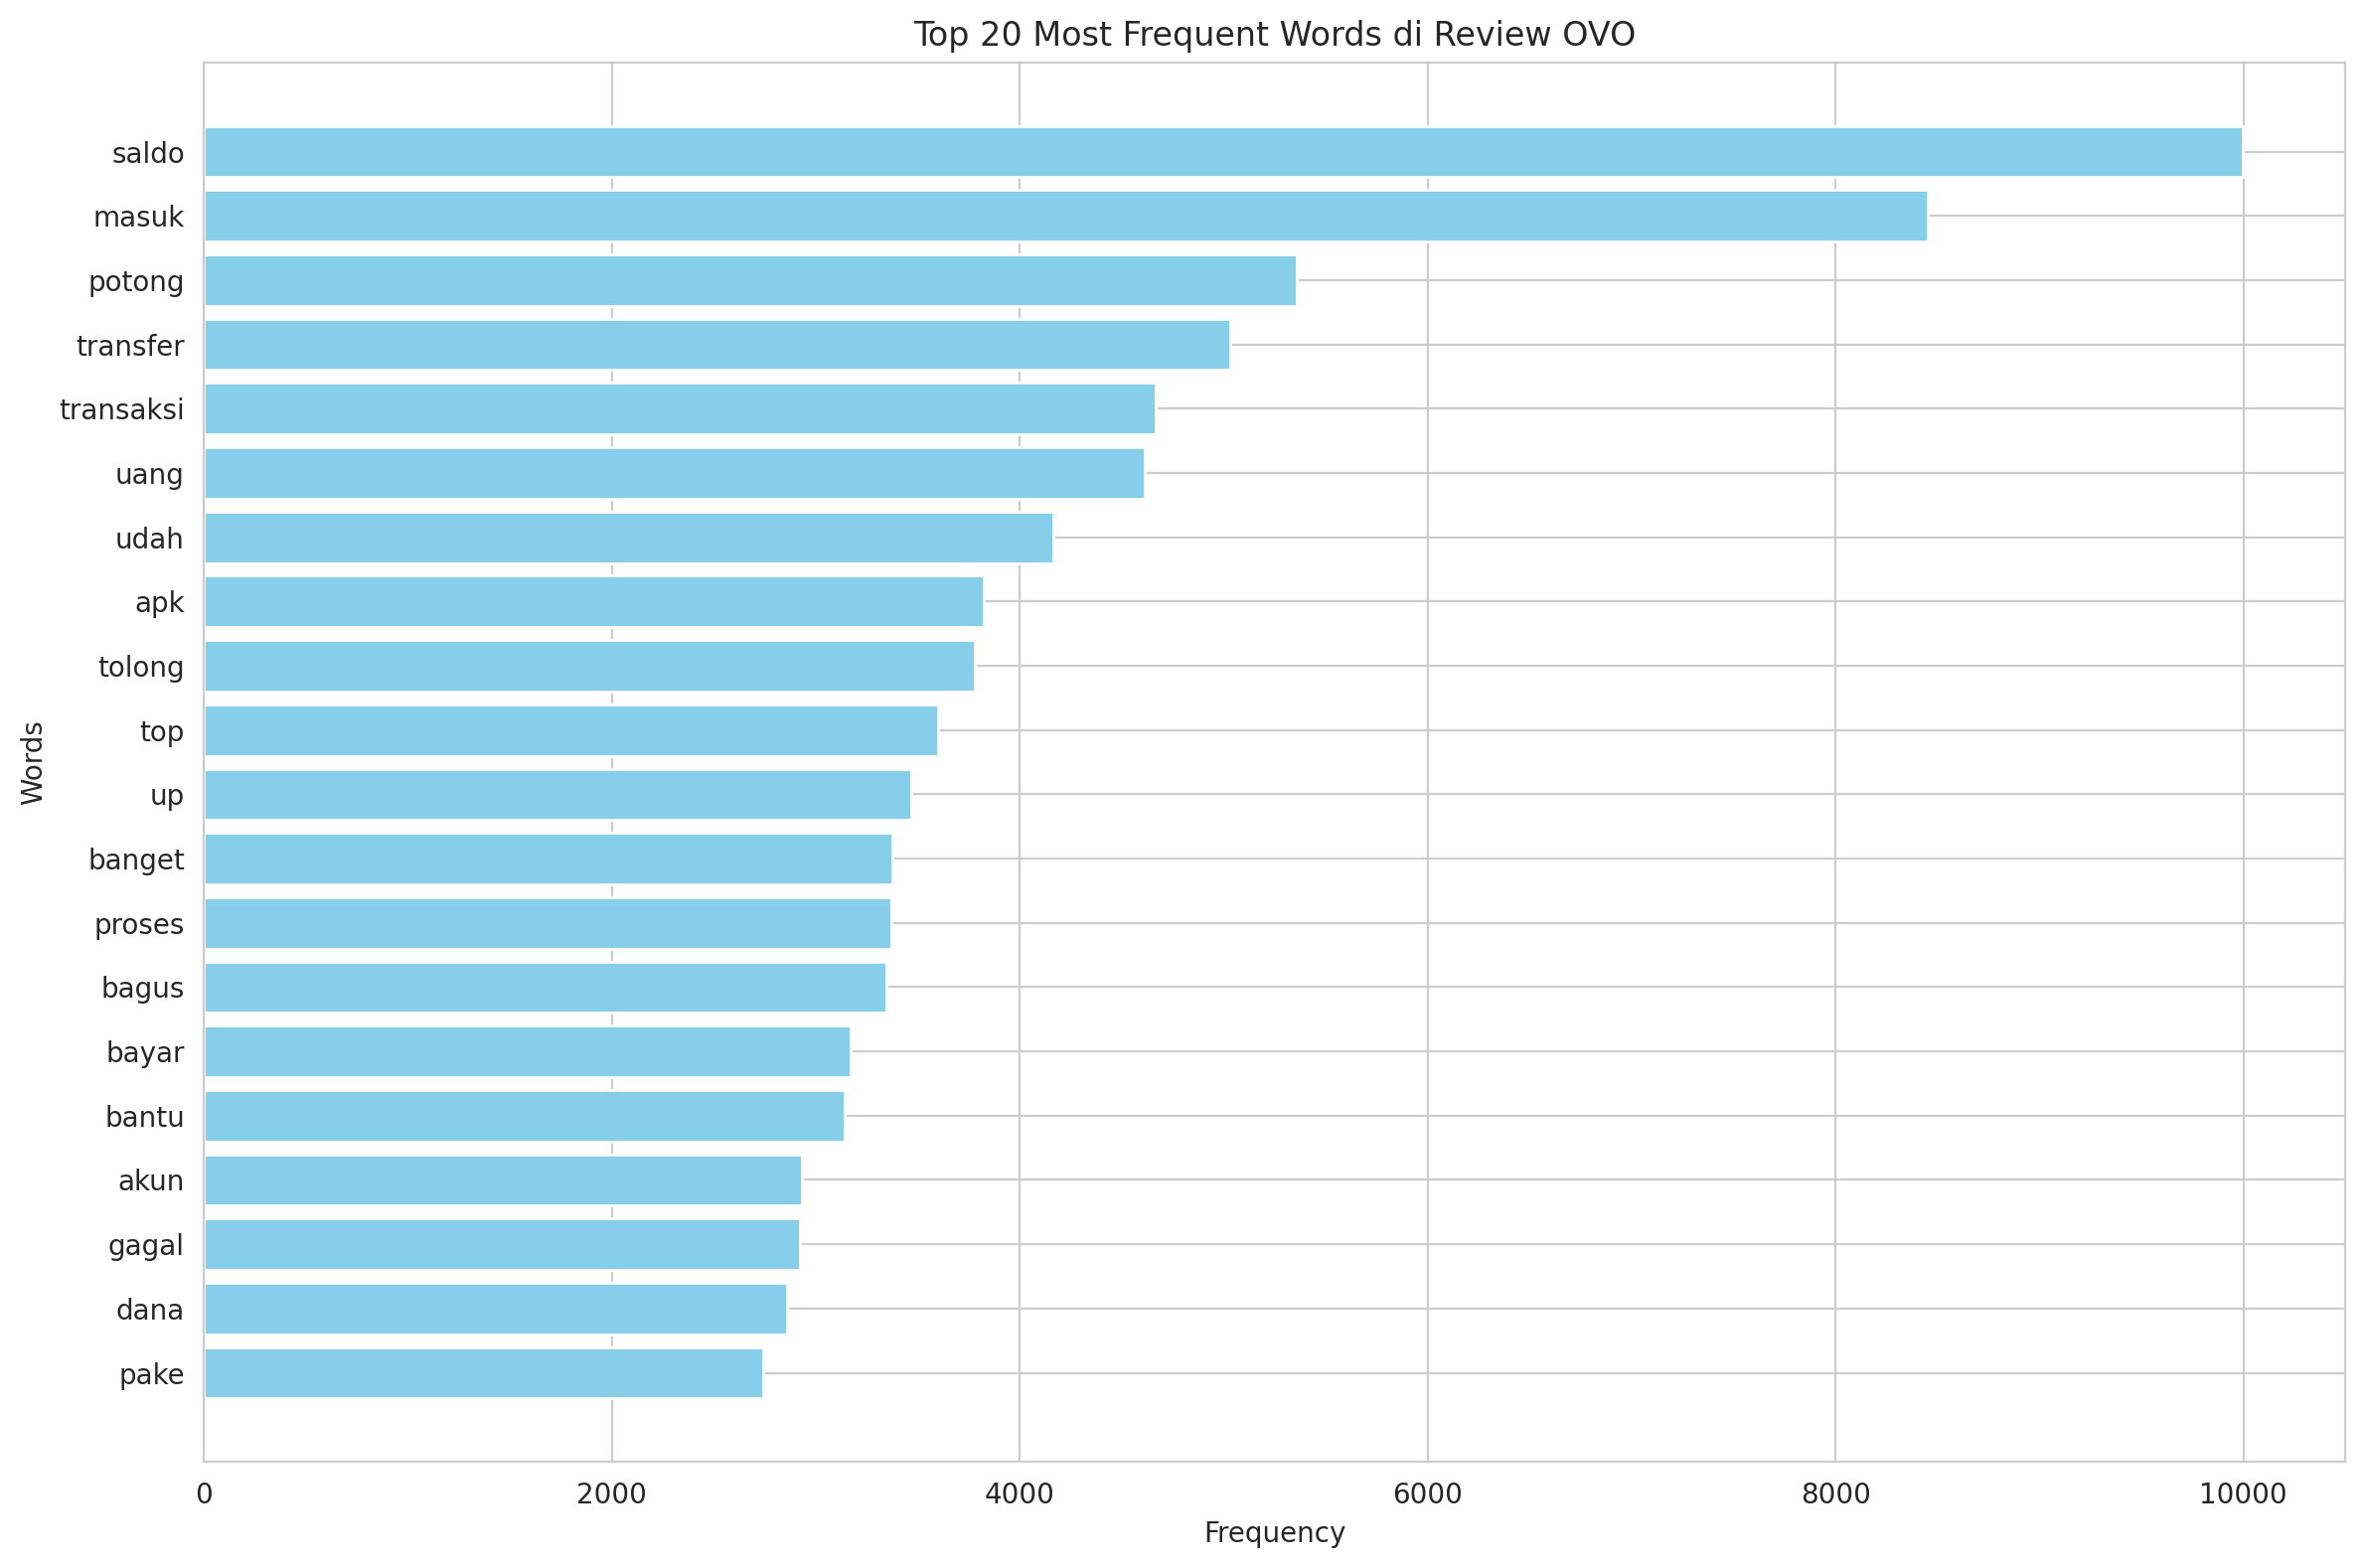

In [ ]:
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
from nltk import FreqDist

# 1. Mengambil semua kata dari kolom 'tokens' yang sudah bersih
all_words = [word for tokens in df_mysuperindo['tokens'] for word in tokens]

# 2. Menghitung frekuensi kata
word_counts = Counter(all_words)
common_words_list = word_counts.most_common(100)  # Ambil 100 teratas

# 3. Masukkan ke DataFrame
word_freq_df = pd.DataFrame(common_words_list, columns=['Word', 'Frequency'])

# Tampilkan 100 kata terbanyak dalam bentuk tabel
print("Tabel 100 Kata Terbanyak dari MySuperindo Reviews:")
display(word_freq_df)

# 4. Membuat Visualisasi Grafik (Top 20)
top_20_df = word_freq_df.head(20)

plt.figure(figsize=(12, 8))
plt.barh(top_20_df['Word'][::-1], top_20_df['Frequency'][::-1], color='skyblue')
plt.xlabel("Frequency")
plt.ylabel("Words")
plt.title("Top 20 Most Frequent Words in MySuperindo Reviews")
plt.tight_layout()
plt.show()


In [ ]:
# Scatter Plot Visualization - Polarity vs Subjectivity (from Week 2)
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 10))
sns.scatterplot(
    data=df_mysuperindo,
    x='sentiment_polarity',
    y='sentiment_subjective',
    hue='sentiment_rating',
    edgecolor='white',
    palette="pastel",
    s=100
)
plt.title("Google Play Store MySuperindo Reviews - Sentiment Analysis (Polarity vs Subjectivity)", fontsize=16)
plt.xlabel("Sentiment Polarity (Negative ← → Positive)")
plt.ylabel("Sentiment Subjectivity (Objective ← → Subjective)")
plt.legend(title='Sentiment Rating', loc='best')
plt.grid(True, alpha=0.3)
plt.show()

# Display data dengan semua features
print("\n=== Final Data with All Features ===")
df_mysuperindo.loc[:,["content","score","sentiment_polarity", "sentiment_subjective","sentiment_rating","wordCount","specialCharCount"]]


In [ ]:
# Score Distribution Visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram
axes[0].hist(df_mysuperindo['score'], bins=5, color='steelblue', edgecolor='black')
axes[0].set_title("Distribution of Review Scores")
axes[0].set_xlabel("Score (Rating)")
axes[0].set_ylabel("Frequency")
axes[0].grid(True, alpha=0.3)

# Countplot
score_counts = df_mysuperindo['score'].value_counts().sort_index()
axes[1].bar(score_counts.index, score_counts.values, color='coral', edgecolor='black')
axes[1].set_title("Review Scores Count")
axes[1].set_xlabel("Rating")
axes[1].set_ylabel("Number of Reviews")
axes[1].set_xticks([1, 2, 3, 4, 5])
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\nScore Distribution Summary:")
print(df_mysuperindo['score'].value_counts().sort_index())
print(f"\nSentiment Rating Distribution:")
print(df_mysuperindo['sentiment_rating'].value_counts())


## Data Saving & Export

Menyimpan hasil preprocessing ke file CSV untuk Machine Learning dan analisis lebih lanjut.


In [ ]:
# Save Before Preprocessing (dengan sentiment features)
filename_before = 'mysuperindo_reviews_before_preprocessing.csv'
df_before_export = df_mysuperindo[['content','score','sentiment_polarity', 'sentiment_subjective','sentiment_rating','wordCount','uppercaseCharCount','specialCharCount']]
df_before_export.to_csv(filename_before, index=False)
print(f"✓ File berhasil disimpan: {filename_before}")

# Save After Preprocessing (clean text)
filename_after = 'mysuperindo_reviews_after_preprocessing.csv'
df_after_export = df_mysuperindo[['content','score','sentiment_polarity', 'sentiment_subjective','sentiment_rating','tokens','clean_text','polarity_clean','sentiment_clean']]
df_after_export.to_csv(filename_after, index=False)
print(f"✓ File berhasil disimpan: {filename_after}")

# Save Complete Dataset
filename_complete = 'mysuperindo_reviews_complete.csv'
df_mysuperindo.to_csv(filename_complete, index=False)
print(f"✓ File berhasil disimpan: {filename_complete}")

print(f"\nTotal data exported: {len(df_mysuperindo)} reviews")


In [ ]:
# Final Summary & Data Preview
print("="*80)
print("SUMMARY: MySuperindo App Reviews - Advanced Preprocessing & Sentiment Analysis")
print("="*80)
print(f"\n📊 Dataset Statistics:")
print(f"   Total Reviews: {len(df_mysuperindo)}")
print(f"   Date Range: {df_mysuperindo['at'].min()} to {df_mysuperindo['at'].max()}")
print(f"\n⭐ Score Distribution:")
for score in sorted(df_mysuperindo['score'].unique()):
    count = (df_mysuperindo['score'] == score).sum()
    pct = (count / len(df_mysuperindo)) * 100
    print(f"   {int(score)} Stars: {count} ({pct:.1f}%)")

print(f"\n💭 Sentiment Rating Distribution:")
for rating in df_mysuperindo['sentiment_rating'].unique():
    count = (df_mysuperindo['sentiment_rating'] == rating).sum()
    pct = (count / len(df_mysuperindo)) * 100
    print(f"   {rating}: {count} ({pct:.1f}%)")

print(f"\n📈 Polarity Statistics:")
print(f"   Mean: {df_mysuperindo['sentiment_polarity'].mean():.4f}")
print(f"   Min: {df_mysuperindo['sentiment_polarity'].min():.4f}")
print(f"   Max: {df_mysuperindo['sentiment_polarity'].max():.4f}")

print(f"\n📝 Text Statistics:")
print(f"   Average Word Count: {df_mysuperindo['wordCount'].mean():.1f}")
print(f"   Max Word Count: {df_mysuperindo['wordCount'].max()}")
print(f"   Min Word Count: {df_mysuperindo['wordCount'].min()}")

print("\n" + "="*80)
print("✅ PREPROCESSING COMPLETED SUCCESSFULLY!")
print("="*80)
